In [5]:
import matplotlib.pyplot as plt
import collections
import numpy as np
from agent_analysis import *

{8: 'blue', 7: 'purple', 19: 'green', 28: 'gray', 38: 'pink', 14: 'red', 35: 'yellow', 41: 'orange', 37: 'brown', 11: 'teal', 23: 'tan', 16: 'aqua', 25: 'olive', 12: 'sky', 13: 'grass', 6: 'turquoise', 24: 'neon', 40: 'gold', 48: 'lime', 34: 'mauve', 29: 'magenta', 0: 'mustard', 31: 'dull', 18: 'barney', 43: 'bright', 45: 'violet', 47: 'rose', 39: 'beige', 26: 'lavender', 20: 'concrete', 42: 'salmon', 27: 'fuchsia', 21: 'pumpkin', 2: 'maroon', 30: 'grape', 36: 'sage', 10: 'caca', 3: 'lavander', 5: 'blood', 1: 'cyan', 15: 'seafoam', 17: 'clay', 44: 'seagreen', 46: 'khaki', 9: 'grapes', 22: 'drab', 33: 'mint', 4: 'medium', 32: 'peach'}


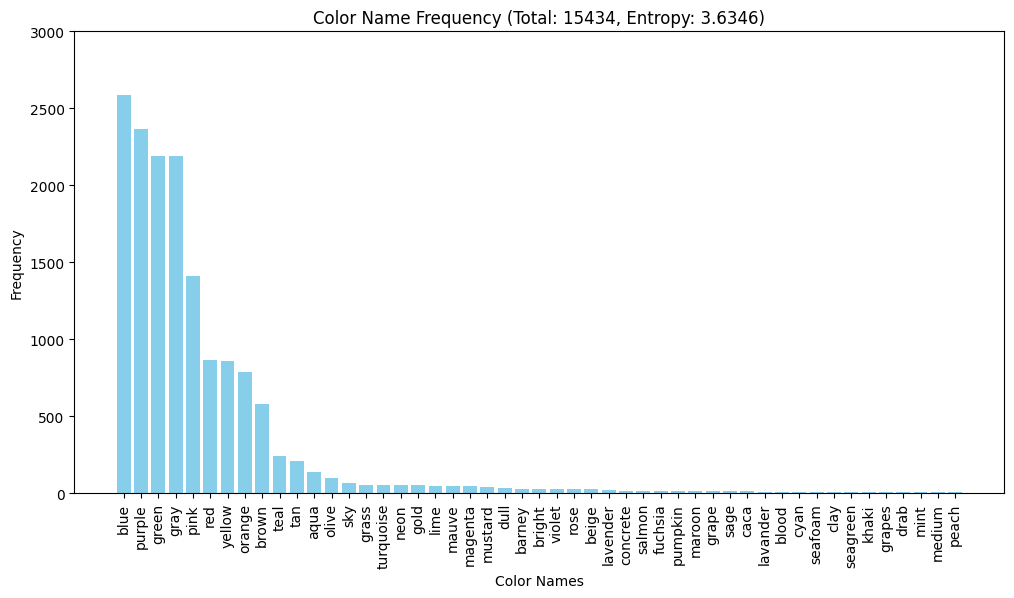

Entropy of the color frequency distribution: 3.6346


In [2]:
# Define the fixed color order
id_to_colors = {
    0: 'mustard', 1: 'cyan', 2: 'maroon', 3: 'lavander', 4: 'medium', 5: 'blood', 6: 'turquoise', 7: 'purple',
    8: 'blue', 9: 'grapes', 10: 'caca', 11: 'teal', 12: 'sky', 13: 'grass', 14: 'red', 15: 'seafoam', 16: 'aqua',
    17: 'clay', 18: 'barney', 19: 'green', 20: 'concrete', 21: 'pumpkin', 22: 'drab', 23: 'tan', 24: 'neon',
    25: 'olive', 26: 'lavender', 27: 'fuchsia', 28: 'gray', 29: 'magenta', 30: 'grape', 31: 'dull', 32: 'peach',
    33: 'mint', 34: 'mauve', 35: 'yellow', 36: 'sage', 37: 'brown', 38: 'pink', 39: 'beige', 40: 'gold',
    41: 'orange', 42: 'salmon', 43: 'bright', 44: 'seagreen', 45: 'violet', 46: 'khaki', 47: 'rose', 48: 'lime'
}

fixed_color_order = list(id_to_colors.values())

# Read the file and count occurrences of each color
color_counts = collections.Counter()

# ======== filter unccessful trials =========
with open("../dynamics/successful_trials_cielab.csv", "r") as file:
    for line in file:
        parts = line.strip().split(",")
        color_name = parts[-1]  # Last column contains the color name
        color_counts[color_name] += 1
# ======== filter unccessful trials =========

# df = pd.read_csv("../dynamics/language_use/1_data.csv", usecols=["contents_cleaned"])
# color_counts = df["contents_cleaned"].value_counts().to_dict()

color_frequencies = {color: color_counts[color] if color in color_counts else 0 for color in fixed_color_order}

# Sort colors by frequency (descending order)
sorted_colors = sorted(color_frequencies.items(), key=lambda x: x[1], reverse=True)
sorted_color_names, sorted_frequencies = zip(*sorted_colors)

# Map color names back to their original IDs
sorted_id_to_colors = {key: value for key, value in sorted(id_to_colors.items(), key=lambda x: color_frequencies[x[1]], reverse=True)}

# Print sorted mapping
print(sorted_id_to_colors)

# Calculate total occurrences
total_colors = sum(sorted_frequencies)

# Compute entropy
probabilities = [freq / total_colors for freq in sorted_frequencies if freq > 0]
entropy = -sum(p * np.log2(p) for p in probabilities)

# Plot sorted color frequencies
plt.figure(figsize=(12, 6))
plt.bar(sorted_color_names, sorted_frequencies, color='skyblue')

plt.xlabel("Color Names")
plt.ylabel("Frequency")
plt.title(f"Color Name Frequency (Total: {total_colors}, Entropy: {entropy:.4f})")
plt.xticks(rotation=90)
plt.ylim(0,3000)
plt.show()

# Print entropy value
print(f"Entropy of the color frequency distribution: {entropy:.4f}")


49
[('blue', 506), ('purple', 448), ('green', 434), ('gray', 425), ('pink', 253), ('yellow', 179), ('red', 172), ('orange', 168), ('brown', 105), ('teal', 37), ('tan', 37), ('aqua', 32), ('olive', 23), ('mauve', 16), ('magenta', 14), ('sky', 12), ('gold', 12), ('neon', 11), ('turquoise', 10), ('lime', 10), ('grass', 9), ('violet', 9), ('barney', 6), ('lavender', 6), ('beige', 6), ('grape', 5), ('bright', 5), ('mustard', 4), ('maroon', 4), ('grapes', 4), ('dull', 4), ('sage', 4), ('khaki', 4), ('lavander', 3), ('caca', 3), ('concrete', 3), ('seagreen', 3), ('cyan', 2), ('blood', 2), ('seafoam', 2), ('drab', 2), ('medium', 1), ('clay', 1), ('fuchsia', 1), ('peach', 1), ('salmon', 1), ('rose', 1), ('pumpkin', 0), ('mint', 0)]


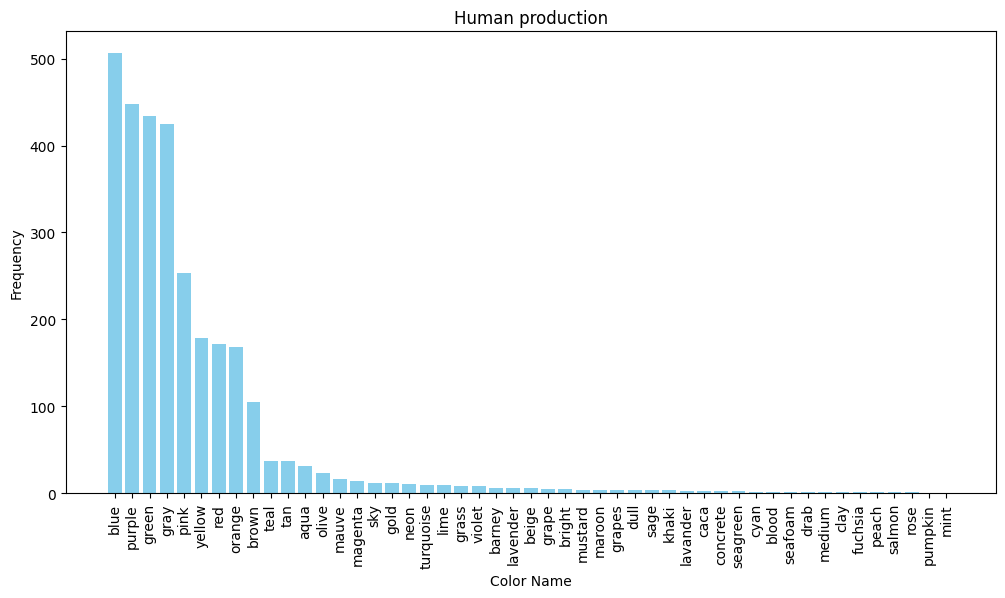

Saved histogram for Epoch 0


In [3]:
seeds_directories = ['../condition1_human/dump_context/msg_spk_seed111']
run_color_analysis_human(seeds_directories)

Processing seed directory: ../condition1_human/dump_context/msg_spk_seed111
The number of successful trials in epoch 29: 2208


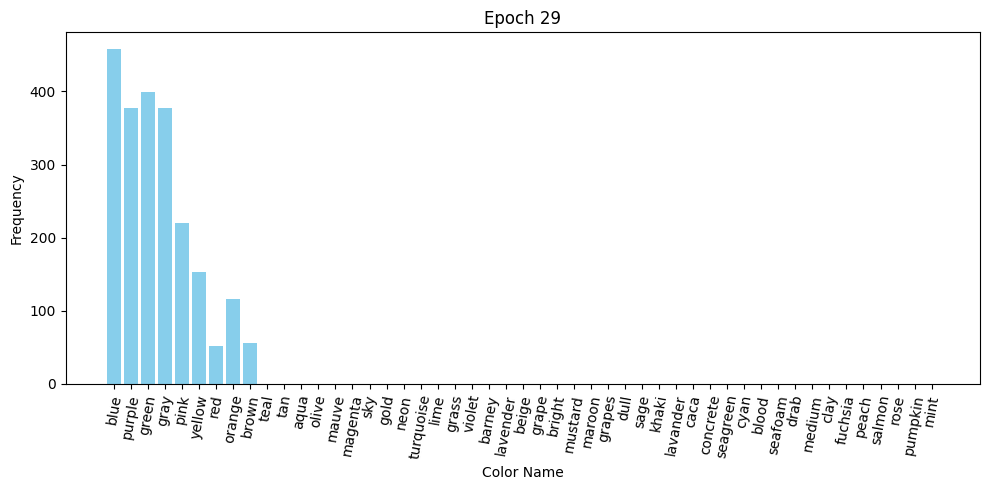

In [4]:
seeds_directories = ['../condition1_human/dump_context/msg_spk_seed111']
freq_dist_agent(seeds_directories, plot_all=False, specific_epoch=29) # 3000 data points --- for humans, and for agents

Processing seed directory: ../condition1_human/dump_context/msg_rf_seed111
The number of successful trials in epoch 0: 2749


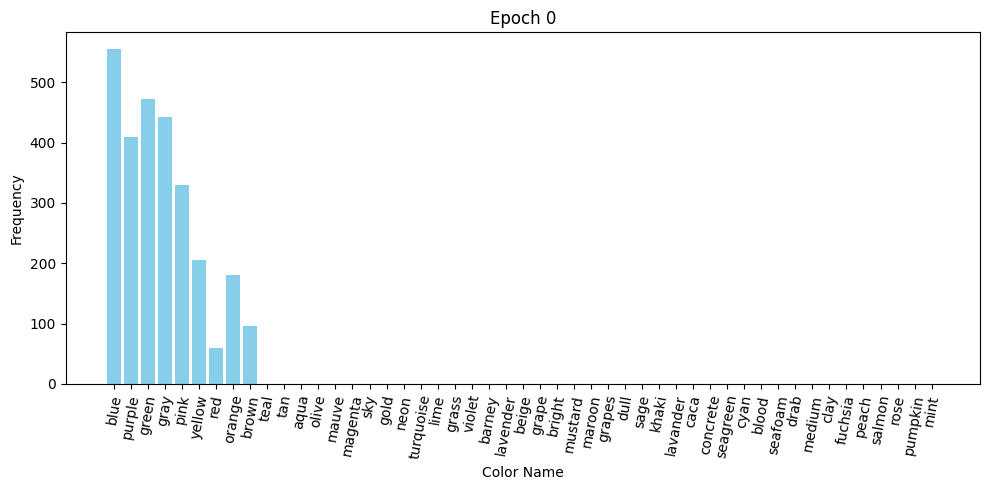

In [5]:
seeds_directories = ['../condition1_human/dump_context/msg_rf_seed111']
freq_dist_agent(seeds_directories, plot_all=False, specific_epoch=0)

Processing seed directory: ../condition1_human/dump_context/msg_rf_seed111
The number of successful trials in epoch 1: 2394


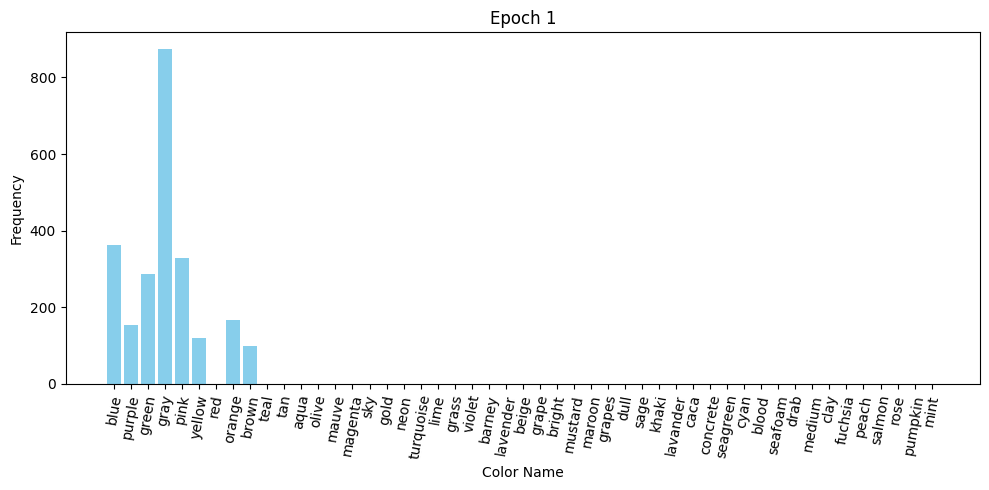

In [6]:
seeds_directories = ['../condition1_human/dump_context/msg_rf_seed111']
freq_dist_agent(seeds_directories, plot_all=False, specific_epoch=1)

Processing seed directory: ../condition3_generated/dump_context/msg_rf_seed111
The number of successful trials in epoch 30: 14473


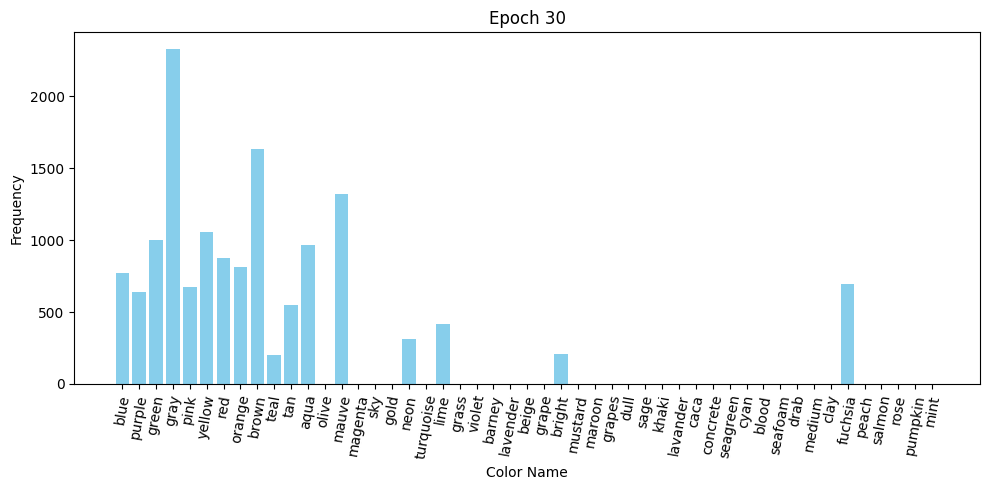

In [6]:
seeds_directories = ['../condition3_generated/dump_context/msg_rf_seed111']
freq_dist_agent(seeds_directories, plot_all=False, specific_epoch=30)

# freq_dist_agent(seeds_directories, plot_all=True)  # plot ~20 rgb colors for each name, but change over time, whether agents categorize colors the same way humans do // prototypes in different epochs to see how it's changing

Processing seed directory: ../dump_context/msg_rf_seed111
The number of successful trials in epoch 30: 14473


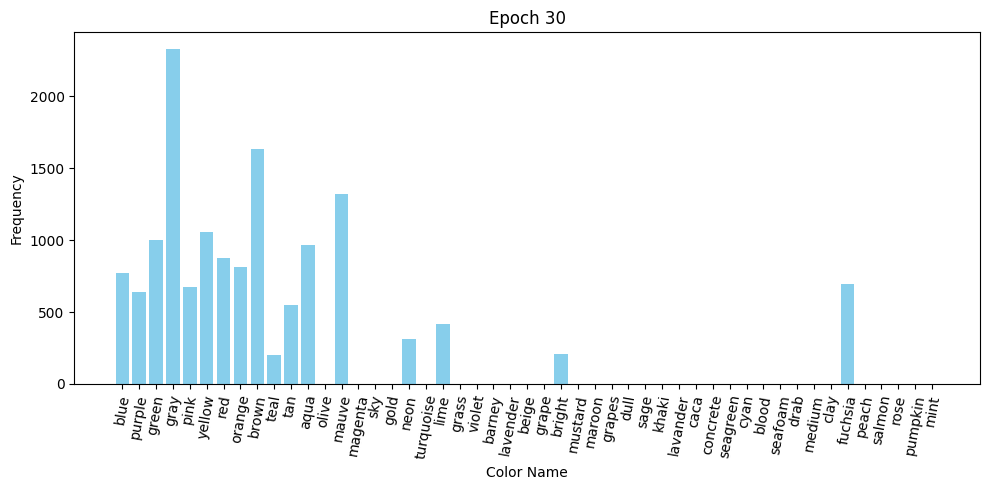

In [2]:
seeds_directories = ['../dump_context/msg_rf_seed111']
freq_dist_agent(seeds_directories, plot_all=False, specific_epoch=30)

Processing seed directory: ../dump_context/msg_rf_seed111


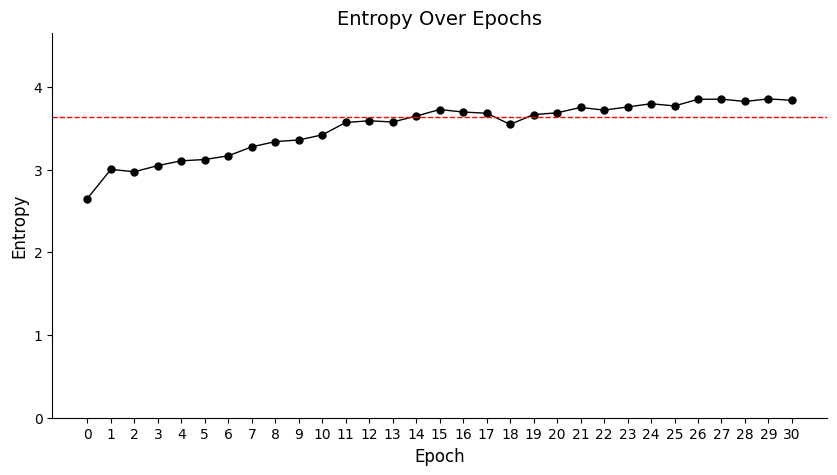

In [3]:
seeds_directories = ['../dump_context/msg_rf_seed111']
# for entropy, all productions not just correct ones
# seeds_directories = ['../exp256_0.001/dump_exp/msg_rf_seed444']
plot_entropy_over_epochs(seeds_directories) # 3.6346

Processing seed directory: ../dump_context/msg_rf_seed111
The number of successful trials in epoch 30: 2778


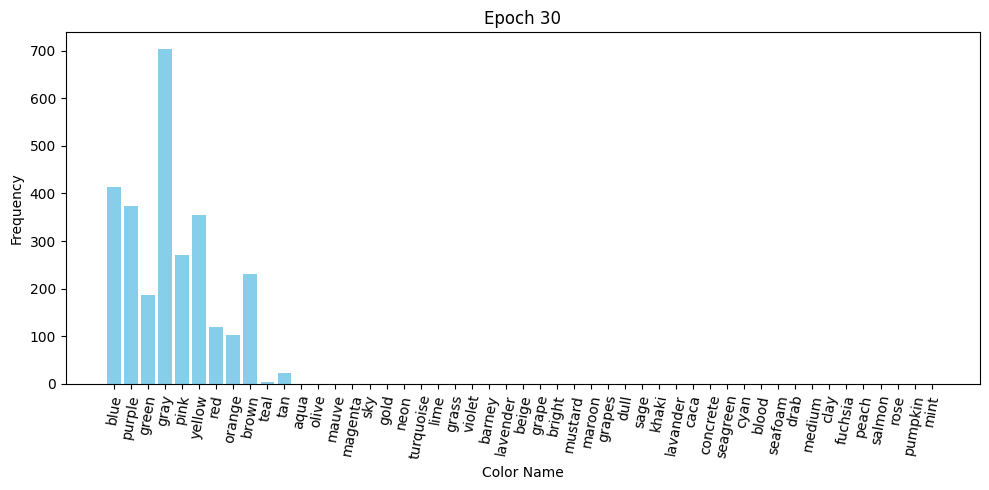

In [2]:
seeds_directories = ['../dump_context/msg_rf_seed111']
freq_dist_agent(seeds_directories, plot_all=False, specific_epoch=30)

In [3]:
from word_informativeness_human3000 import *

file_paths = ['../condition1_human/dump_context/msg_spk_seed111/sender_epoch29.txt']
output_file_path = "../condition1_human/dump_context/epochspk30.txt"

word_informativeness(file_paths, output_file_path)

Processing file: ../condition1_human/dump_context/epochspk30.txt
Informativeness for ../condition1_human/dump_context/epochspk30.txt:
  color_name  informativeness
5       gray         7.401090
8        red         5.588935
6      brown         5.148386
7     orange         3.658729
0     yellow         2.900139
3      green         2.655022
2       pink         2.422735
4     purple         2.376749
1       blue         1.508579


In [1]:
# informativeness: at the level of the whole lexicon 
from word_informativeness_human3000 import *

file_path = '../condition1_human/dump_context/msg_spk_seed111/sender_epoch29.txt'
word_info_path = "../condition1_human/dump_context/epochspk30_informativeness.csv"
process_file_info_system(file_path, word_info_path)
# Lexical System Informativeness for ../dump_exp/msg_rf_seed444/output_epoch30.txt: 2.7062007240857637 ++ type level avg informativeness

Lexical System Informativeness for ../condition1_human/dump_context/msg_spk_seed111/sender_epoch29.txt: 3.7386532059479975


(  color_name  informativeness
 0       gray         7.363944
 1        red         5.588935
 2      brown         5.156837
 3     orange         3.606294
 4     yellow         2.938405
 5      green         2.653749
 6     purple         2.423754
 7       pink         2.399994
 8       blue         1.515966,
 3.7386532059479975)

In [2]:
from informativeness_sl import *

file_paths = ['../condition1_human/dump_context/msg_spk_seed111/sender_epoch29.txt']
output_file_path = "../condition1_human/dump_context/epochspk30.txt"
label = False

process_multiple_files(file_paths, output_file_path, label)

Processing concatenated file: ../condition1_human/dump_context/epochspk30.txt

Lexical System Informativeness for ../condition1_human/dump_context/epochspk30.txt: 3.3166979023681815


(  color_name  informativeness
 5       gray         8.323118
 8        red         5.308334
 6      brown         5.147843
 7     orange         3.342687
 0     yellow         2.977290
 3      green         2.614461
 4     purple         2.390529
 2       pink         2.368243
 1       blue         1.514991,
 3.3166979023681815)

In [1]:
from word_informativeness import *

file_paths = ['../condition1_human/dump_context/msg_rf_seed111/output_epoch30.txt']
output_file_path = "../condition1_human/dump_context/epoch30.txt"

word_informativeness(file_paths, output_file_path)

Processing file: ../condition1_human/dump_context/epoch30.txt
Informativeness for ../condition1_human/dump_context/epoch30.txt:
   color_name  informativeness
3       mauve         2.510468
8       brown         2.421454
5        gray         2.407526
12      olive         2.324196
0      orange         2.130962
13       teal         2.103763
4       green         1.996032
10        tan         1.954017
6      yellow         1.760156
2        pink         1.748611
9      purple         1.698334
14    magenta         1.600034
11       aqua         1.583939
1        blue         1.446055
7        neon         1.003923
15        red         0.000000


In [2]:
# informativeness: at the level of the whole lexicon 
from word_informativeness import *


file_path = '../condition1_human/dump_context/msg_rf_seed111/output_epoch30.txt'
word_info_path = "../condition1_human/dump_context/epoch30_informativeness.csv"
process_file_info_system(file_path, word_info_path)
# Lexical System Informativeness for ../dump_exp/msg_rf_seed444/output_epoch30.txt: 2.7062007240857637 ++ type level avg informativeness

Lexical System Informativeness for ../condition1_human/dump_context/msg_rf_seed111/output_epoch30.txt: 1.793091881711029


(   color_name  informativeness
 0       mauve         2.510468
 1       brown         2.421454
 2        gray         2.407526
 3       olive         2.324196
 4      orange         2.130962
 5        teal         2.103763
 6       green         1.996032
 7         tan         1.954017
 8      yellow         1.760156
 9        pink         1.748611
 10     purple         1.698334
 11    magenta         1.600034
 12       aqua         1.583939
 13       blue         1.446055
 14       neon         1.003923
 15        red         0.000000,
 1.793091881711029)

In [3]:
from word_informativeness import *

file_paths = ['../condition3_generated/dump_context/msg_rf_seed111/output_epoch30.txt']
output_file_path = "../condition3_generated/dump_context/epoch30.txt"

word_informativeness(file_paths, output_file_path)

Processing file: ../condition3_generated/dump_context/epoch30.txt
Informativeness for ../condition3_generated/dump_context/epoch30.txt:
   color_name  informativeness
12       lime         2.347815
11      mauve         2.328023
8       green         2.232737
15       teal         1.952799
9       brown         1.951910
7      purple         1.935439
2         red         1.899895
14    fuchsia         1.885179
10     orange         1.872710
16     bright         1.813099
4        pink         1.793619
17  turquoise         1.754465
1      yellow         1.699825
13        tan         1.659416
6        blue         1.501978
3        neon         1.235522
5        gray         1.210368
0        aqua         1.170656


In [4]:
# informativeness: at the level of the whole lexicon 
from word_informativeness import *

file_path = '../condition3_generated/dump_context/msg_rf_seed111/output_epoch30.txt'
word_info_path = "../condition3_generated/dump_context/epoch30_informativeness.csv"
process_file_info_system(file_path, word_info_path)
# Lexical System Informativeness for ../dump_exp/msg_rf_seed444/output_epoch30.txt: 2.7062007240857637 ++ type level avg informativeness

Lexical System Informativeness for ../condition3_generated/dump_context/msg_rf_seed111/output_epoch30.txt: 1.7914141585109995


(   color_name  informativeness
 0        lime         2.347815
 1       mauve         2.328023
 2       green         2.232737
 3        teal         1.952799
 4       brown         1.951910
 5      purple         1.935439
 6         red         1.899895
 7     fuchsia         1.885179
 8      orange         1.872710
 9      bright         1.813099
 10       pink         1.793619
 11  turquoise         1.754465
 12     yellow         1.699825
 13        tan         1.659416
 14       blue         1.501978
 15       neon         1.235522
 16       gray         1.210368
 17       aqua         1.170656,
 1.7914141585109995)

In [13]:
file_path = '../condition3_generated/dump_context/msg_rf_seed111/output_epoch30.txt'
info_path =  "../condition3_generated/dump_context/epoch30_informativeness.csv"
process_file_infodiff(file_path, info_path) #  --- compute this for humans

far_words, {'purple (none)', 'bright (none)', 'fuchsia (none)', 'turquoise (none)', 'aqua (none)', 'brown (none)', 'gray (none)', 'tan (none)', 'neon (none)', 'pink (none)', 'yellow (none)', 'orange (none)', 'lime (none)', 'mauve (none)', 'teal (none)', 'green (none)', 'red (none)', 'blue (none)'}
close_words, {'purple (none)', 'bright (none)', 'fuchsia (none)', 'aqua (none)', 'brown (none)', 'gray (none)', 'neon (none)', 'yellow (none)', 'pink (none)', 'orange (none)', 'blue (none)', 'lime (none)', 'mauve (none)', 'teal (none)', 'green (none)', 'red (none)', 'tan (none)'}
Words in close_words but not in far_words: set()
Mean Informativeness (Far): 1.7162
Mean Informativeness (Close): 1.8172
Informativeness Difference (Far - Close): -0.1010


(          color_name  informativeness
 0        lime (none)         2.472723
 1       mauve (none)         2.354691
 2       green (none)         2.292117
 3      purple (none)         2.019239
 4       brown (none)         1.941605
 5        teal (none)         1.941423
 6         red (none)         1.895467
 7     fuchsia (none)         1.881294
 8      orange (none)         1.872326
 9      bright (none)         1.817121
 10       pink (none)         1.804859
 11        tan (none)         1.721484
 12     yellow (none)         1.720947
 13       blue (none)         1.513913
 14       gray (none)         1.217586
 15       neon (none)         1.214654
 16       aqua (none)         1.210162
 17  turquoise (none)         0.000000,
 -0.10095297801257619)

spearman correlation: -0.3000


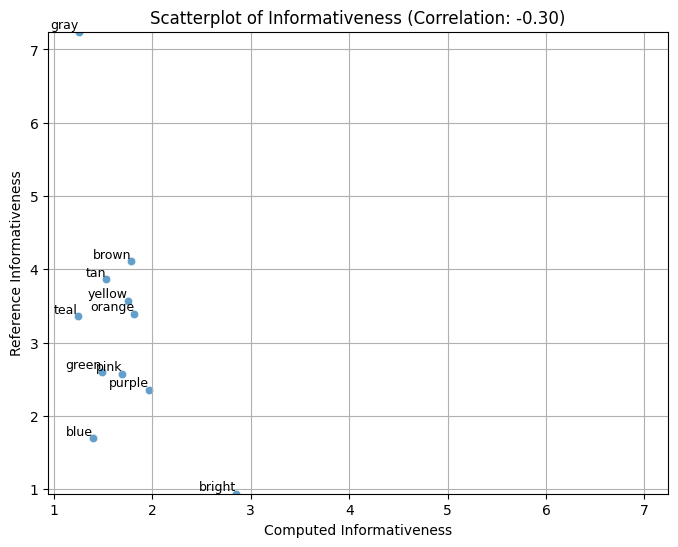

In [8]:
computed_informativeness_file = "../dump_context/epoch30_informativeness.csv"
# computed_informativeness_file = "../exp256_0.001/dump_exp/epoch30_informativeness.csv" 
reference_file = "../dynamics/language_use/informativeness/dic_informativeness.csv"
correlate_word_informativeness(computed_informativeness_file, reference_file, method="spearman") # --- spearman correlation, use all data, the same as humans

pearson correlation: 0.0452


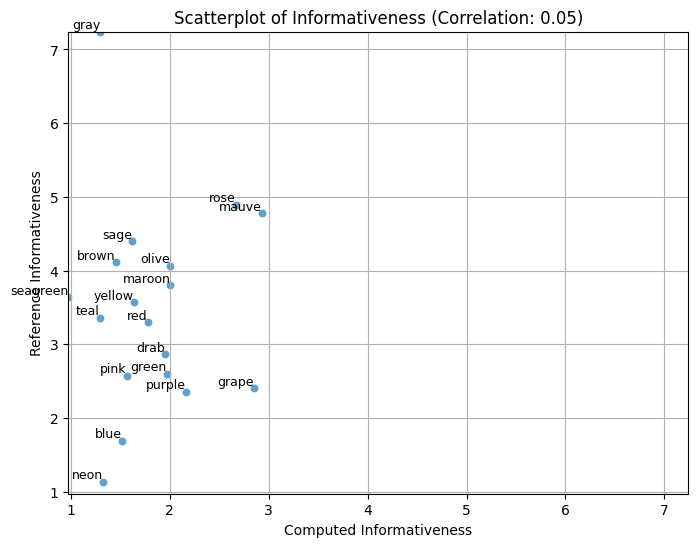

In [13]:
computed_informativeness_file = "../dump_exp/epoch30_informativeness.csv"
reference_file = "../dynamics/language_use/informativeness/dic_informativeness.csv"
correlate_word_informativeness(computed_informativeness_file, reference_file, method="pearson") # --- spearman correlation

## Visualize Prototypes

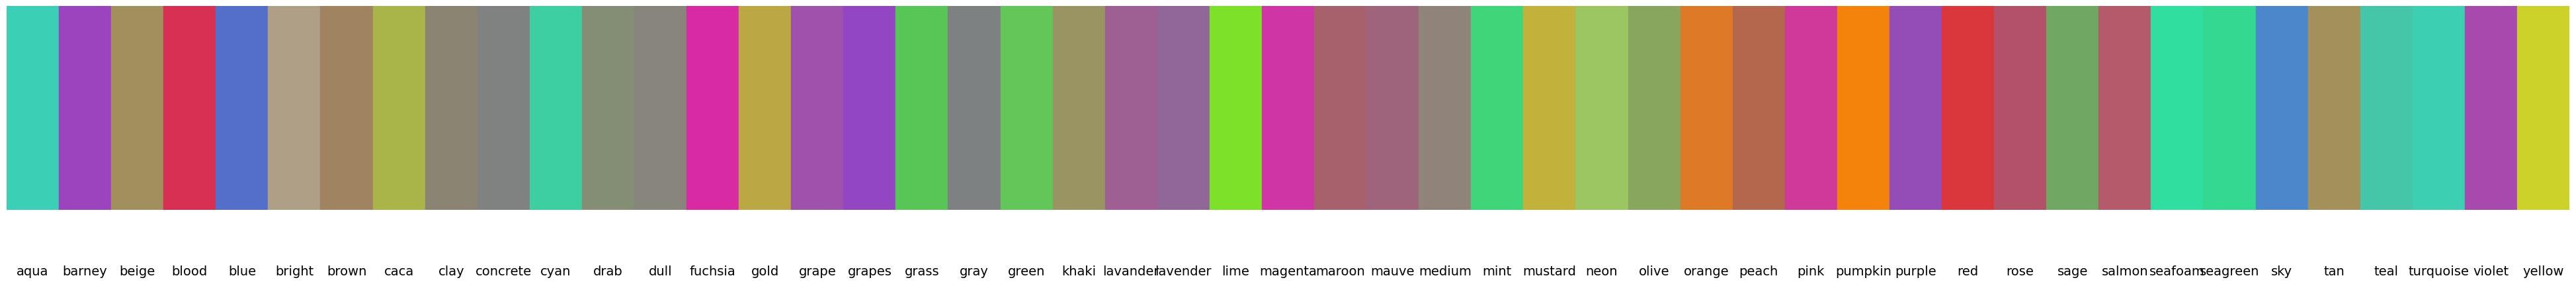

In [2]:
visualize_prototypes("../dynamics/language_use/prototypes.pkl")

Prototypes saved successfully to prototypes_spk.pkl!
Prototypes saved successfully to prototypes_spk.csv!


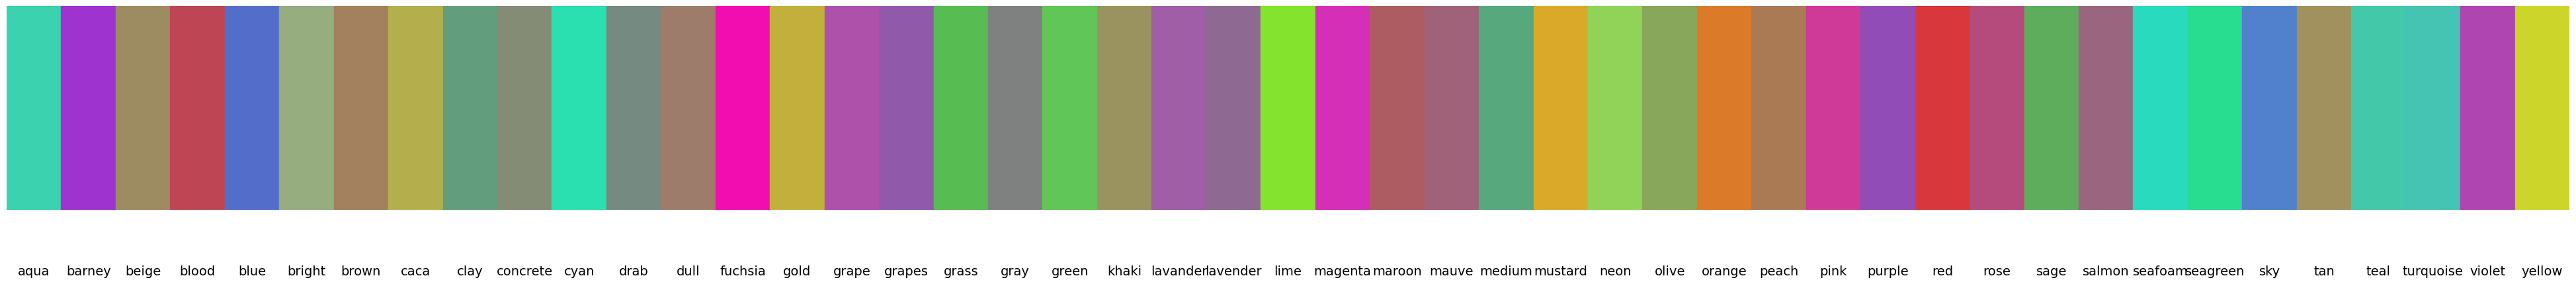

In [18]:
compute_prototype("../dump_context/msg_spk_seed111/sender_epoch29.txt", "prototypes_spk.pkl", "prototypes_spk.csv")
visualize_prototypes("./prototypes_spk.pkl")

Prototypes saved successfully to prototypes0.pkl!
Prototypes saved successfully to prototypes0.csv!


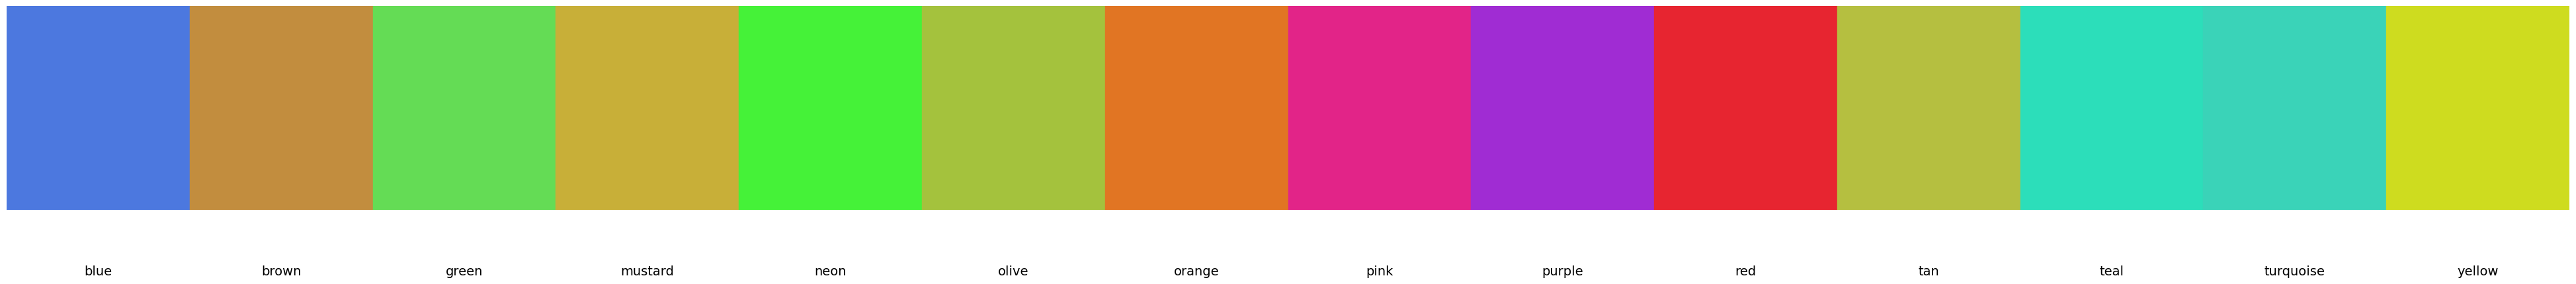

In [19]:
compute_prototype("../dump_context/msg_rf_seed111/output_epoch0.txt", "prototypes0.pkl", "prototypes0.csv")
visualize_prototypes("./prototypes0.pkl")

Prototypes saved successfully to prototypes1.pkl!
Prototypes saved successfully to prototypes1.csv!


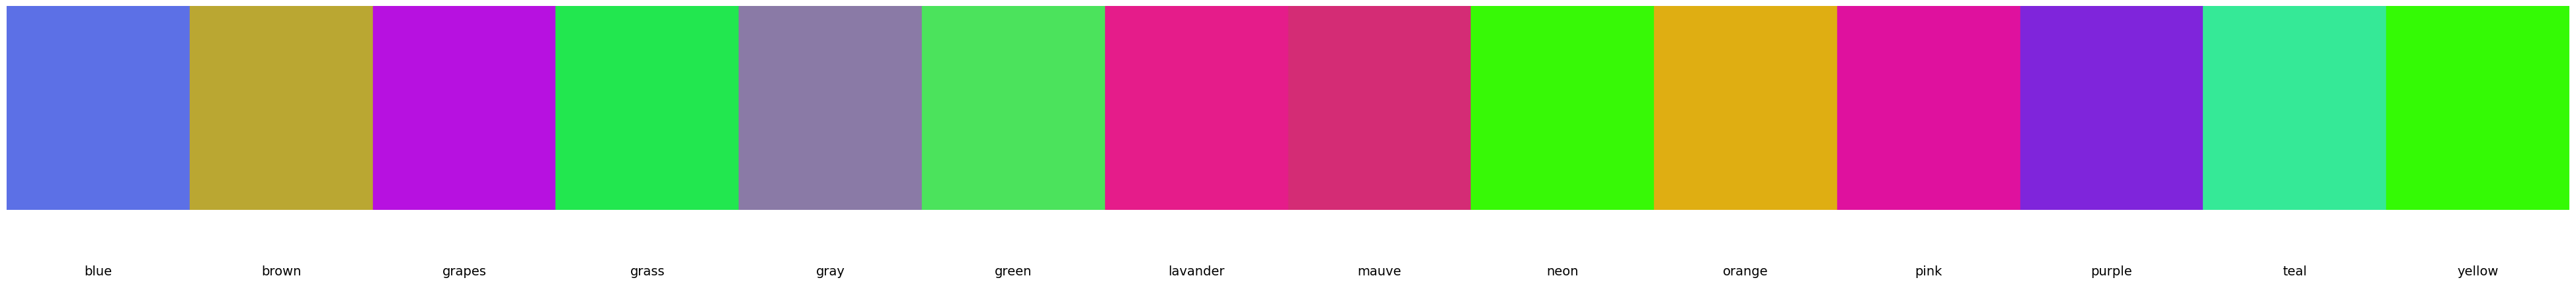

In [20]:
compute_prototype("../dump_context/msg_rf_seed111/output_epoch1.txt", "prototypes1.pkl", "prototypes1.csv")
visualize_prototypes("./prototypes1.pkl")

Prototypes saved successfully to prototypes10.pkl!
Prototypes saved successfully to prototypes10.csv!


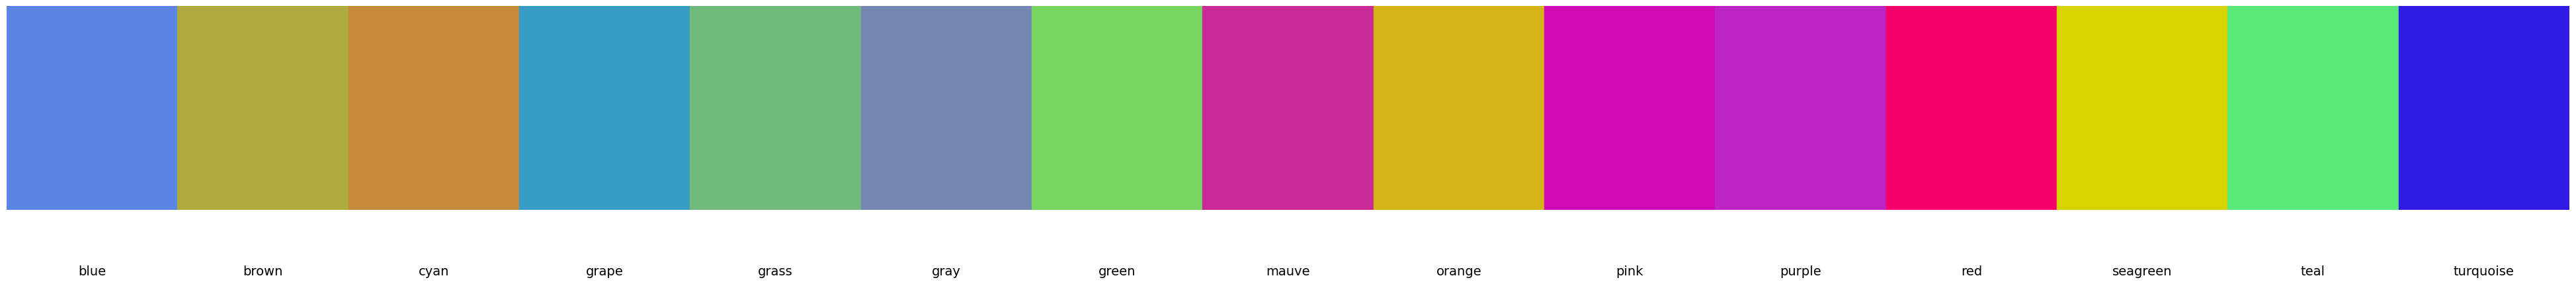

In [21]:
compute_prototype("../dump_context/msg_rf_seed111/output_epoch10.txt", "prototypes10.pkl", "prototypes10.csv")
visualize_prototypes("./prototypes10.pkl")

Prototypes saved successfully to prototypes20.pkl!
Prototypes saved successfully to prototypes20.csv!


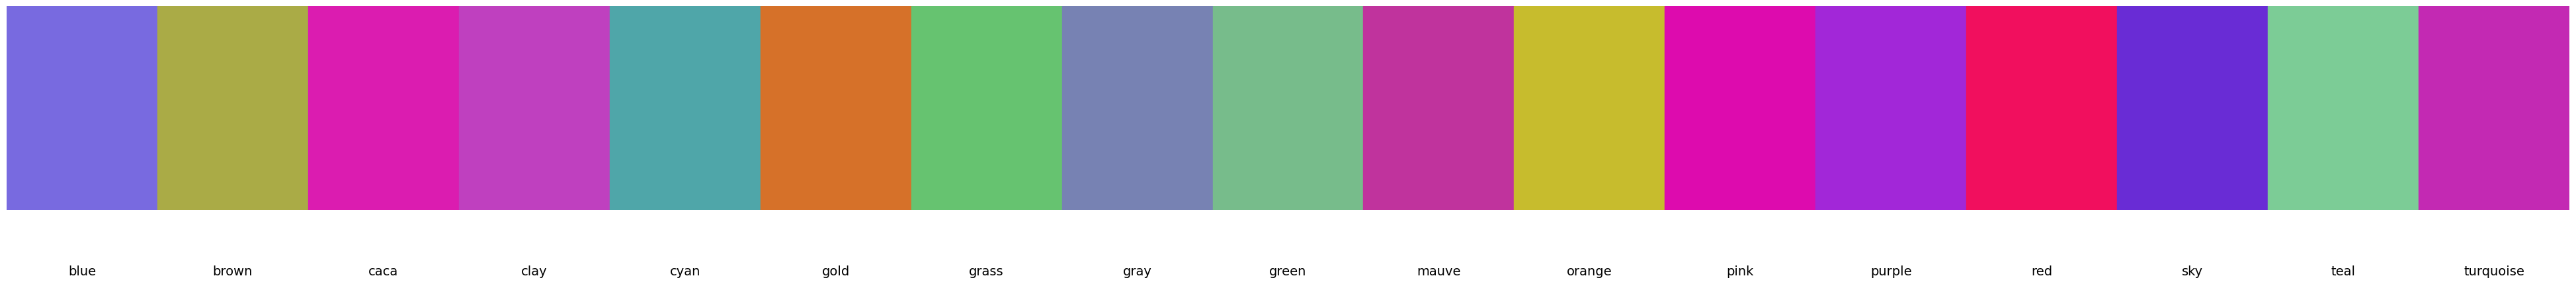

In [23]:
compute_prototype("../dump_context/msg_rf_seed111/output_epoch20.txt", "prototypes20.pkl", "prototypes20.csv")
visualize_prototypes("./prototypes20.pkl")

Prototypes saved successfully to prototypes30.pkl!
Prototypes saved successfully to prototypes30.csv!


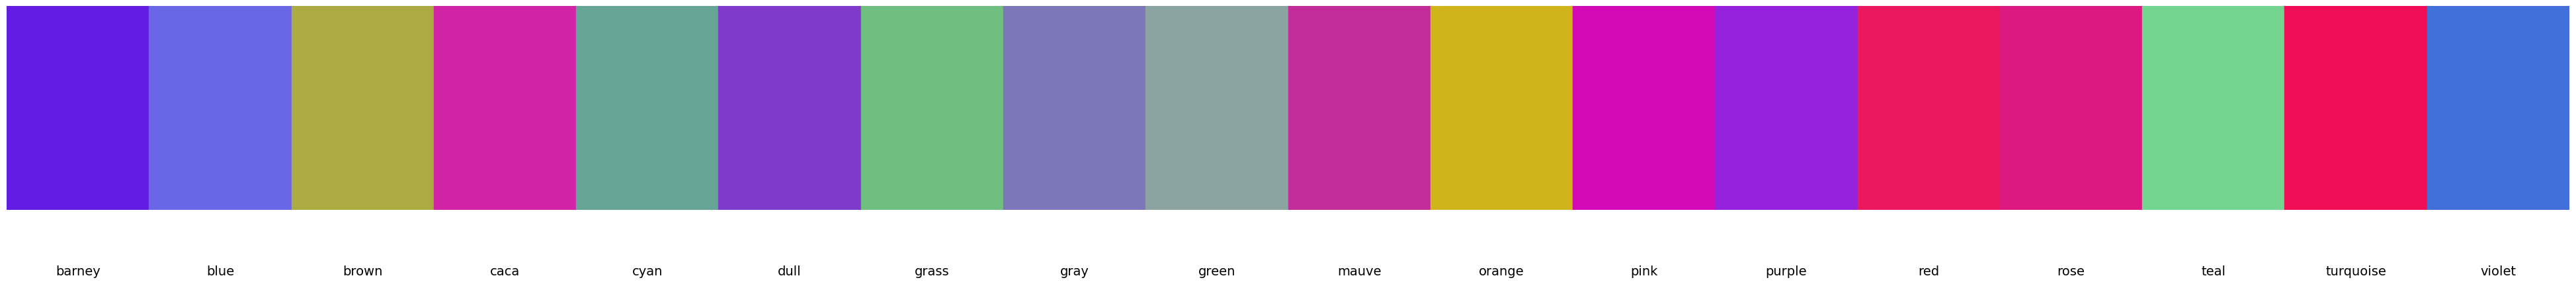

In [24]:
compute_prototype("../dump_context/msg_rf_seed111/output_epoch30.txt", "prototypes30.pkl", "prototypes30.csv")
visualize_prototypes("./prototypes30.pkl")  # --- add this for the end of sl
# diverge so much with the generated data // check the exact colors used for // now computed for the last epoch // olive-turquoise // beige-brown-drab-peach-tan // concrete-purple-gray ---- check a few intermediate epochs
# the metrics for measuring drift
# distance to the use of humans (dist between human prototype & agent prototype) -- if the data is the same --- cielabspace distance // check emnlp paper // problem: some colors disappear -- avg?
# better than measuring speaker accuracy

## Analyzing Typicality

In [1]:
from agent_analysis import *
analyze_typicality("../dump_context/msg_rf_seed111/output_epoch30.txt", "prototypes30.pkl", "typicality_results.csv") # break down: different contexts, different typicalities -- sometimes use less typical // dist2name and dist2other differently used in different context (far, close), frequency of names is different
# because of the frequency effect, cyan-blue, when blue is further away than cyan (more matched)

Results saved successfully to typicality_results.csv!
Average dist2name: 56.882
Average dist2other: 18.581


In [7]:
from agent_analysis import *
analyze_typicality_human("../dynamics/successful_trials_cielab.csv", "../dynamics/language_use/dic_informativeness.pkl", "typicality_results_human.csv")

Results saved successfully to typicality_results_human.csv!
Average dist2name: 81.471
Average dist2other: 79.088
